# Predictive Modeling

The goal of this notebook is to test whether current-season player information can predict next-season player value.

A key modeling concern is feature overlap. Many football metrics measure similar things: raw EPA, standardized value scores, yards, touchdowns, fantasy points, and efficiency stats are often correlated. Instead of putting every feature into one model, this notebook compares separate feature sets. That makes the modeling process more defensible and helps show which kind of information is most useful.

The primary target is `next_season_value_score`, which is next season's position-adjusted total-EPA value score. This target is standardized within season-position groups, making it better suited for a single model across QBs, RBs, WRs, and TEs. Raw next-season EPA is retained for interpretation, but the first modeling pass focuses on predicting relative next-season value.


## Load Data and Packages

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")


def find_project_root(expected_file):
    """Find the repo root from common VS Code/Jupyter working directories."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / expected_file).exists():
            return candidate
    raise FileNotFoundError(
        "Could not find " + expected_file + " from working directory " + str(Path.cwd())
    )

project_root = find_project_root("data/processed/player_value_scores_2016_2025.csv")
processed_dir = project_root / "data" / "processed"
figures_dir = project_root / "outputs" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

value_scores_path = processed_dir / "player_value_scores_2016_2025.csv"
value_scored = pd.read_csv(value_scores_path)

print(value_scored.shape)
value_scored.head()


(4796, 84)


,season,player_id,player_name,player_display_name,position,team,completions,attempts,passing_yards,passing_tds,...,value_epa_total,value_epa_per_game,value_score_total_epa,value_score_per_game,value_score,value_metric,scrimmage_epa_z,scrimmage_epa_per_game_z,position_season_rank,position_season_percentile
0,2016,00-0019596,T.Brady,Tom Brady,QB,NE,291,432,3554,28,...,140.632333,11.719361,2.127596,2.264787,2.127596,position_adjusted_total_epa,NaN,NaN,3.0,0.96
1,2016,00-0020531,D.Brees,Drew Brees,QB,NO,471,673,5208,37,...,105.672159,6.604510,1.491620,1.172466,1.491620,position_adjusted_total_epa,NaN,NaN,6.0,0.90
2,2016,00-0021206,J.McCown,Josh McCown,QB,CLE,90,165,1100,6,...,-29.051473,-5.810295,-0.959196,-1.478825,-0.959196,position_adjusted_total_epa,NaN,NaN,45.0,0.12
3,2016,00-0021429,C.Palmer,Carson Palmer,QB,ARI,364,597,4233,26,...,26.261320,1.750755,0.047023,0.135903,0.047023,position_adjusted_total_epa,NaN,NaN,20.0,0.62
4,2016,00-0022803,E.Manning,Eli Manning,QB,NYG,377,598,4027,26,...,-20.212029,-1.263252,-0.798394,-0.507764,-0.798394,position_adjusted_total_epa,NaN,NaN,41.0,0.20


## Collapse to One Row Per Player-Season

The value-score dataset is stored at the player-season-team level so traded players can be inspected by team stint. For next-season prediction, however, the natural modeling unit is one player-season. A player who changes teams during a season should still have one current-season row and one next-season target.

This section collapses team-stint rows into player-season rows by summing counting stats and then recalculating the value metrics. Standardized scores are recalculated after the collapse so the model uses clean player-season features.


In [2]:
identity_cols = ["season", "player_id"]

sum_cols = [
    "completions", "attempts", "passing_yards", "passing_tds",
    "passing_interceptions", "sacks_suffered", "sack_yards_lost",
    "passing_air_yards", "passing_yards_after_catch", "passing_first_downs",
    "passing_epa", "passing_2pt_conversions",
    "carries", "rushing_yards", "rushing_tds", "rushing_first_downs",
    "rushing_epa", "rushing_2pt_conversions",
    "targets", "receptions", "receiving_yards", "receiving_tds",
    "receiving_air_yards", "receiving_yards_after_catch",
    "receiving_first_downs", "receiving_epa", "receiving_2pt_conversions",
    "fantasy_points", "fantasy_points_ppr", "games_played"
]

sum_cols = [col for col in sum_cols if col in value_scored.columns]

first_cols = [
    "player_name", "player_display_name", "position", "birth_date", "height",
    "weight", "years_exp", "entry_year", "rookie_year", "draft_club",
    "draft_number", "college", "age"
]
first_cols = [col for col in first_cols if col in value_scored.columns]

agg_spec = {col: "sum" for col in sum_cols}
agg_spec.update({col: "first" for col in first_cols})
agg_spec["team"] = lambda x: "/".join(sorted(x.dropna().astype(str).unique()))

player_season = (
    value_scored
    .groupby(identity_cols, as_index=False)
    .agg(agg_spec)
)

# Recalculate derived season-level features after collapsing team stints.
player_season["total_yards"] = (
    player_season.get("passing_yards", 0) +
    player_season.get("rushing_yards", 0) +
    player_season.get("receiving_yards", 0)
)
player_season["total_tds"] = (
    player_season.get("passing_tds", 0) +
    player_season.get("rushing_tds", 0) +
    player_season.get("receiving_tds", 0)
)
player_season["total_epa"] = (
    player_season.get("passing_epa", 0) +
    player_season.get("rushing_epa", 0) +
    player_season.get("receiving_epa", 0)
)
player_season["yards_per_game"] = player_season["total_yards"] / player_season["games_played"]
player_season["tds_per_game"] = player_season["total_tds"] / player_season["games_played"]
player_season["epa_per_game"] = player_season["total_epa"] / player_season["games_played"]

player_season["scrimmage_touches"] = player_season.get("carries", 0) + player_season.get("receptions", 0)
player_season["scrimmage_yards"] = player_season.get("rushing_yards", 0) + player_season.get("receiving_yards", 0)
player_season["scrimmage_tds"] = player_season.get("rushing_tds", 0) + player_season.get("receiving_tds", 0)
player_season["scrimmage_epa"] = player_season.get("rushing_epa", 0) + player_season.get("receiving_epa", 0)
player_season["scrimmage_yards_per_game"] = player_season["scrimmage_yards"] / player_season["games_played"]
player_season["scrimmage_touches_per_game"] = player_season["scrimmage_touches"] / player_season["games_played"]
player_season["scrimmage_tds_per_game"] = player_season["scrimmage_tds"] / player_season["games_played"]
player_season["scrimmage_epa_per_game"] = player_season["scrimmage_epa"] / player_season["games_played"]
player_season["yards_per_scrimmage_touch"] = (
    player_season["scrimmage_yards"] / player_season["scrimmage_touches"].replace(0, np.nan)
)

player_season["qb_plays"] = player_season.get("attempts", 0) + player_season.get("carries", 0)
player_season["qb_total_yards"] = player_season.get("passing_yards", 0) + player_season.get("rushing_yards", 0)
player_season["qb_total_tds"] = player_season.get("passing_tds", 0) + player_season.get("rushing_tds", 0)
player_season["qb_epa"] = player_season.get("passing_epa", 0) + player_season.get("rushing_epa", 0)
player_season["qb_yards_per_play"] = player_season["qb_total_yards"] / player_season["qb_plays"].replace(0, np.nan)
player_season["qb_yards_per_game"] = player_season["qb_total_yards"] / player_season["games_played"]
player_season["qb_tds_per_game"] = player_season["qb_total_tds"] / player_season["games_played"]
player_season["qb_epa_per_game"] = player_season["qb_epa"] / player_season["games_played"]
player_season["interceptions_per_game"] = player_season.get("passing_interceptions", 0) / player_season["games_played"]

player_season["value_epa_total"] = np.where(
    player_season["position"].eq("QB"),
    player_season["qb_epa"],
    player_season["scrimmage_epa"]
)
player_season["value_epa_per_game"] = player_season["value_epa_total"] / player_season["games_played"]

player_season.shape


(4729, 72)

## Recalculate Standardized Value Scores

After collapsing to player-season rows, standardized scores are recalculated within each season-position group. This avoids using team-stint z-scores for players who changed teams.

In [3]:
def add_group_zscore(df, value_col, z_col, group_cols=["season", "position"]):
    df = df.copy()
    group_mean = df.groupby(group_cols)[value_col].transform("mean")
    group_std = df.groupby(group_cols)[value_col].transform("std")
    df[z_col] = (df[value_col] - group_mean) / group_std
    return df

player_season = add_group_zscore(player_season, "value_epa_total", "value_score")
player_season = add_group_zscore(player_season, "value_epa_per_game", "value_score_per_game")
player_season["value_score_gap"] = player_season["value_score_per_game"] - player_season["value_score"]

print(player_season.shape)
print("Duplicate player-season rows:", player_season.duplicated(["season", "player_id"]).sum())
player_season[[
    "season", "player_display_name", "position", "team", "games_played",
    "value_epa_total", "value_epa_per_game", "value_score", "value_score_per_game"
]].head()


(4729, 75)
Duplicate player-season rows: 0


,season,player_display_name,position,team,games_played,value_epa_total,value_epa_per_game,value_score,value_score_per_game
0,2016,Tom Brady,QB,NE,12,140.632333,11.719361,2.127596,2.264787
1,2016,Steve Smith,WR,BAL,14,37.947165,2.710512,1.391023,1.433619
2,2016,Drew Brees,QB,NO,16,105.672159,6.604510,1.491620,1.172466
3,2016,Josh McCown,QB,CLE,5,-29.051473,-5.810295,-0.959196,-1.478825
4,2016,Carson Palmer,QB,ARI,15,26.261320,1.750755,0.047023,0.135903


## Create Next-Season Targets

The main target is `next_season_value_score`, which is the player's standardized total-EPA value in the following season. The notebook only creates a target when the next row for a player is exactly the next calendar season. This prevents accidental links across gaps, such as 2019 directly to 2021 if a player missed 2020.


In [4]:
player_season = player_season.sort_values(["player_id", "season"]).copy()

for col in ["season", "value_epa_total", "value_epa_per_game", "value_score", "value_score_per_game"]:
    player_season["next_" + col] = player_season.groupby("player_id")[col].shift(-1)

has_next_consecutive_season = player_season["next_season"].eq(player_season["season"] + 1)

target_cols = [
    "next_value_epa_total", "next_value_epa_per_game",
    "next_value_score", "next_value_score_per_game"
]
for col in target_cols:
    player_season.loc[~has_next_consecutive_season, col] = np.nan

modeling_df = player_season.dropna(subset=["next_value_score"]).copy()

print("Player-season rows:", player_season.shape)
print("Rows with next-season target:", modeling_df.shape)
modeling_df[[
    "season", "player_display_name", "position", "team",
    "value_score", "next_season", "next_value_score"
]].head()


Player-season rows: (4729, 80)
Rows with next-season target: (3066, 80)


,season,player_display_name,position,team,value_score,next_season,next_value_score
0,2016,Tom Brady,QB,NE,2.127596,2017.0,2.242667
449,2017,Tom Brady,QB,NE,2.242667,2018.0,1.071892
908,2018,Tom Brady,QB,NE,1.071892,2019.0,0.167967
1374,2019,Tom Brady,QB,NE,0.167967,2020.0,1.301862
1827,2020,Tom Brady,QB,TB,1.301862,2021.0,2.245321


## Feature Overlap Check

This heatmap shows why the notebook compares feature sets instead of throwing every variable into one model. Some features are alternative versions of the same signal, such as raw EPA and standardized EPA, or total EPA and EPA per game.

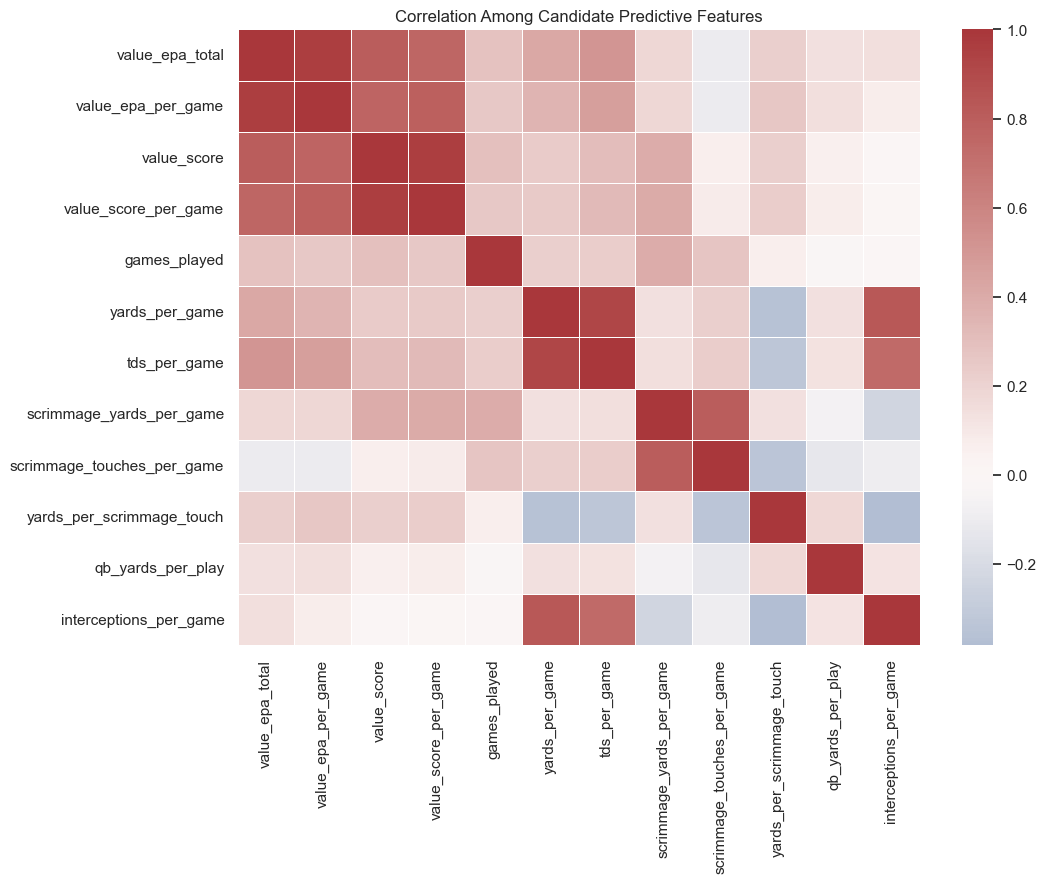

In [5]:
overlap_cols = [
    "value_epa_total", "value_epa_per_game", "value_score", "value_score_per_game",
    "games_played", "yards_per_game", "tds_per_game",
    "scrimmage_yards_per_game", "scrimmage_touches_per_game",
    "yards_per_scrimmage_touch", "qb_yards_per_play", "interceptions_per_game"
]

overlap_cols = [col for col in overlap_cols if col in modeling_df.columns]

plt.figure(figsize=(11, 8))
sns.heatmap(modeling_df[overlap_cols].corr(numeric_only=True), cmap="vlag", center=0, linewidths=0.5)
plt.title("Correlation Among Candidate Predictive Features")
plt.show()


## Train, Validation, and Test Split

The split is time-aware rather than random. This is important because the project is trying to predict future seasons from past information.

- Train: 2016-2022 seasons
- Validation: 2023 season
- Test: 2024 season

The 2024 test rows predict 2025 value, so 2025 is used as the target season but not as a feature season.


In [6]:
train_df = modeling_df[modeling_df["season"].between(2016, 2022)].copy()
valid_df = modeling_df[modeling_df["season"].eq(2023)].copy()
development_df = modeling_df[modeling_df["season"].between(2016, 2023)].copy()
test_df = modeling_df[modeling_df["season"].eq(2024)].copy()

target = "next_value_score"

print("Train:", train_df.shape, train_df["season"].min(), train_df["season"].max())
print("Validation:", valid_df.shape, valid_df["season"].unique())
print("Development for final fit:", development_df.shape, development_df["season"].min(), development_df["season"].max())
print("Test:", test_df.shape, test_df["season"].unique())


Train: (2351, 80) 2016 2022
Validation: (350, 80) [2023]
Development for final fit: (2701, 80) 2016 2023
Test: (365, 80) [2024]


## Define Feature Sets

Each feature set avoids a different kind of overlap.

- `profile`: player context and availability only.
- `raw_production`: raw EPA and box-score production, without standardized duplicate metrics.
- `standardized_value`: standardized value metrics only, without raw EPA duplicates.
- `usage_efficiency`: usage and efficiency features that describe how production happened.

This design lets the project compare modeling approaches instead of assuming all correlated features belong in one model.


In [7]:
feature_sets = {
    "profile": [
        "position", "age", "years_exp", "draft_number", "games_played"
    ],
    "raw_production": [
        "position", "age", "years_exp", "draft_number", "games_played",
        "value_epa_total", "value_epa_per_game", "yards_per_game", "tds_per_game"
    ],
    "standardized_value": [
        "position", "age", "years_exp", "draft_number", "games_played",
        "value_score", "value_score_per_game", "value_score_gap"
    ],
    "usage_efficiency": [
        "position", "age", "years_exp", "draft_number", "games_played",
        "attempts", "carries", "targets", "receptions",
        "scrimmage_touches_per_game", "yards_per_scrimmage_touch",
        "scrimmage_tds_per_game", "qb_yards_per_play", "qb_tds_per_game",
        "interceptions_per_game"
    ]
}

# Keep only columns that exist, so the notebook is robust to earlier data-source changes.
feature_sets = {
    name: [col for col in cols if col in modeling_df.columns]
    for name, cols in feature_sets.items()
}

feature_sets


{'profile': ['position', 'age', 'years_exp', 'draft_number', 'games_played'],
 'raw_production': ['position',
  'age',
  'years_exp',
  'draft_number',
  'games_played',
  'value_epa_total',
  'value_epa_per_game',
  'yards_per_game',
  'tds_per_game'],
 'standardized_value': ['position',
  'age',
  'years_exp',
  'draft_number',
  'games_played',
  'value_score',
  'value_score_per_game',
  'value_score_gap'],
 'usage_efficiency': ['position',
  'age',
  'years_exp',
  'draft_number',
  'games_played',
  'attempts',
  'carries',
  'targets',
  'receptions',
  'scrimmage_touches_per_game',
  'yards_per_scrimmage_touch',
  'scrimmage_tds_per_game',
  'qb_yards_per_play',
  'qb_tds_per_game',
  'interceptions_per_game']}

## Model Setup

The first model is a dummy baseline that always predicts the training-set average. The other models test whether player profile, production, and usage features add predictive signal.

Linear models are useful because they are interpretable, but correlated features can make coefficients unstable. Ridge regression helps with that by shrinking coefficients. Tree-based models can capture nonlinear patterns, but their feature importances should be interpreted carefully when features overlap.


In [8]:
models = {
    "dummy_mean": DummyRegressor(strategy="mean"),
    "linear_regression": LinearRegression(),
    "ridge": Ridge(alpha=10.0),
    "random_forest": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    "gradient_boosting": GradientBoostingRegressor(random_state=42)
}


def make_pipeline(feature_cols, model):
    categorical_cols = [col for col in feature_cols if col == "position"]
    numeric_cols = [col for col in feature_cols if col not in categorical_cols]

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ],
        remainder="drop"
    )

    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])


def evaluate_predictions(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred)
    }


## Train and Compare Models

The results table reports validation and test metrics for each model-feature-set combination. Model selection should be based on validation performance; the test set is the final check on the selected approach.

In [9]:
results = []
fitted_models = {}

for feature_set_name, feature_cols in feature_sets.items():
    X_train = train_df[feature_cols]
    y_train = train_df[target]
    X_valid = valid_df[feature_cols]
    y_valid = valid_df[target]
    X_test = test_df[feature_cols]
    y_test = test_df[target]

    for model_name, model in models.items():
        if model_name == "dummy_mean" and feature_set_name != "profile":
            continue

        pipeline = make_pipeline(feature_cols, clone(model))
        pipeline.fit(X_train, y_train)

        valid_pred = pipeline.predict(X_valid)
        test_pred = pipeline.predict(X_test)

        valid_metrics = evaluate_predictions(y_valid, valid_pred)
        test_metrics = evaluate_predictions(y_test, test_pred)

        results.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "n_features": len(feature_cols),
            "valid_mae": valid_metrics["mae"],
            "valid_rmse": valid_metrics["rmse"],
            "valid_r2": valid_metrics["r2"],
            "test_mae": test_metrics["mae"],
            "test_rmse": test_metrics["rmse"],
            "test_r2": test_metrics["r2"]
        })

        fitted_models[(feature_set_name, model_name)] = pipeline

results_df = pd.DataFrame(results).sort_values(["valid_rmse", "test_rmse"])
results_df


,feature_set,model,n_features,valid_mae,valid_rmse,valid_r2,test_mae,test_rmse,test_r2
7,raw_production,random_forest,9,0.673534,0.941482,0.207063,0.642634,0.939461,0.172031
8,raw_production,gradient_boosting,9,0.678108,0.951174,0.190653,0.657864,0.943281,0.165286
16,usage_efficiency,gradient_boosting,15,0.686689,0.954964,0.184192,0.642469,0.942409,0.166828
11,standardized_value,random_forest,8,0.718940,0.968095,0.161602,0.656049,0.941423,0.168570
6,raw_production,ridge,9,0.716680,0.968176,0.161463,0.688645,0.963205,0.129651
5,raw_production,linear_regression,9,0.716623,0.968220,0.161387,0.689529,0.963751,0.128665
14,usage_efficiency,ridge,15,0.706132,0.968598,0.160731,0.650381,0.937617,0.175278
15,usage_efficiency,random_forest,15,0.703559,0.969514,0.159143,0.651119,0.940691,0.169862
13,usage_efficiency,linear_regression,15,0.708114,0.970478,0.157469,0.652410,0.936917,0.176510
9,standardized_value,linear_regression,8,0.717949,0.971331,0.155988,0.659020,0.940151,0.170815


## Visualize Model Results

This chart compares validation RMSE across model and feature-set combinations. Lower values are better. If a more complex feature set does not beat a simpler one, that suggests the extra overlapping features may not be adding useful signal.

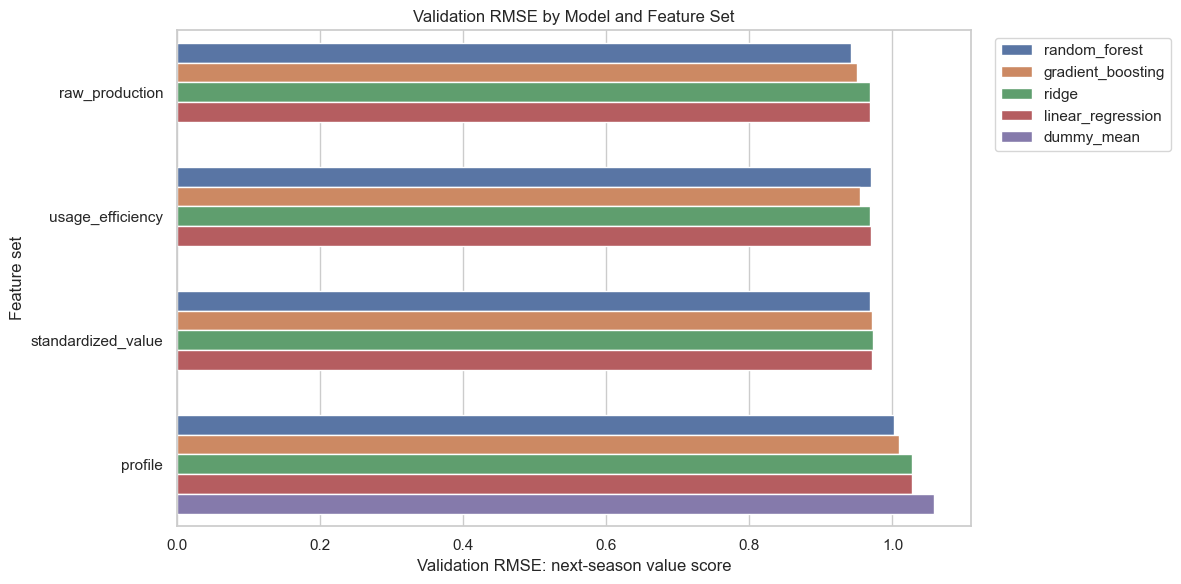

In [10]:
plt.figure(figsize=(12, 6))
plot_results = results_df.sort_values("valid_rmse")
sns.barplot(data=plot_results, x="valid_rmse", y="feature_set", hue="model")
plt.title("Validation RMSE by Model and Feature Set")
plt.xlabel("Validation RMSE: next-season value score")
plt.ylabel("Feature set")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Hyperparameter Tuning With Rolling Validation

The first model comparison used one validation season: 2023. That is useful, but it can make the results too dependent on one NFL season. This section tunes the main model families with rolling, football-time-aware validation folds.

Each fold trains on earlier seasons and validates on the next season. The 2024 test season stays untouched until after the best tuned setup is chosen.


In [11]:
rolling_validation_years = [2020, 2021, 2022, 2023]
rolling_folds = []

for valid_year in rolling_validation_years:
    fold_train = modeling_df[modeling_df["season"].lt(valid_year)].copy()
    fold_valid = modeling_df[modeling_df["season"].eq(valid_year)].copy()

    if not fold_train.empty and not fold_valid.empty:
        rolling_folds.append({
            "valid_year": valid_year,
            "train": fold_train,
            "valid": fold_valid
        })

pd.DataFrame({
    "valid_year": [fold["valid_year"] for fold in rolling_folds],
    "train_rows": [len(fold["train"]) for fold in rolling_folds],
    "valid_rows": [len(fold["valid"]) for fold in rolling_folds],
    "train_start": [fold["train"]["season"].min() for fold in rolling_folds],
    "train_end": [fold["train"]["season"].max() for fold in rolling_folds]
})


,valid_year,train_rows,valid_rows,train_start,train_end
0,2020,1304,350,2016,2019
1,2021,1654,355,2016,2020
2,2022,2009,342,2016,2021
3,2023,2351,350,2016,2022


In [12]:
tuning_models = {
    "ridge": Ridge(),
    "random_forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "gradient_boosting": GradientBoostingRegressor(random_state=42)
}

tuning_grids = {
    "ridge": {
        "alpha": [0.1, 1.0, 10.0, 50.0, 100.0]
    },
    "random_forest": {
        "n_estimators": [300],
        "max_depth": [5, 10, None],
        "min_samples_leaf": [3, 10],
        "max_features": ["sqrt", 0.75]
    },
    "gradient_boosting": {
        "n_estimators": [100, 250],
        "learning_rate": [0.03, 0.07],
        "max_depth": [2, 3],
        "min_samples_leaf": [5, 15],
        "subsample": [0.8]
    }
}

# Profile-only models are useful as a baseline, but tuning focuses on feature sets
# that contain football production signals.
tuning_feature_sets = [
    "raw_production",
    "standardized_value",
    "usage_efficiency"
]

tuning_records = []

for feature_set_name in tuning_feature_sets:
    feature_cols = feature_sets[feature_set_name]

    for model_name, base_model in tuning_models.items():
        for params in ParameterGrid(tuning_grids[model_name]):
            params_json = json.dumps(params, sort_keys=True)

            for fold in rolling_folds:
                fold_train = fold["train"]
                fold_valid = fold["valid"]

                model = clone(base_model).set_params(**params)
                pipeline = make_pipeline(feature_cols, model)
                pipeline.fit(fold_train[feature_cols], fold_train[target])

                valid_pred = pipeline.predict(fold_valid[feature_cols])
                valid_metrics = evaluate_predictions(fold_valid[target], valid_pred)

                tuning_records.append({
                    "feature_set": feature_set_name,
                    "model": model_name,
                    "params_json": params_json,
                    "valid_year": fold["valid_year"],
                    "valid_mae": valid_metrics["mae"],
                    "valid_rmse": valid_metrics["rmse"],
                    "valid_r2": valid_metrics["r2"]
                })

tuning_fold_results_df = pd.DataFrame(tuning_records)

tuning_results_df = (
    tuning_fold_results_df
    .groupby(["feature_set", "model", "params_json"], as_index=False)
    .agg(
        mean_valid_mae=("valid_mae", "mean"),
        mean_valid_rmse=("valid_rmse", "mean"),
        std_valid_rmse=("valid_rmse", "std"),
        mean_valid_r2=("valid_r2", "mean")
    )
    .sort_values(["mean_valid_rmse", "std_valid_rmse"])
)

tuning_results_df.head(15)


,feature_set,model,params_json,mean_valid_mae,mean_valid_rmse,std_valid_rmse,mean_valid_r2
22,raw_production,random_forest,"{""max_depth"": 5, ""max_features"": 0.75, ""min_sa...",0.695268,0.937595,0.012738,0.216952
18,raw_production,random_forest,"{""max_depth"": 10, ""max_features"": 0.75, ""min_s...",0.691757,0.939461,0.010914,0.213793
16,raw_production,random_forest,"{""max_depth"": 10, ""max_features"": ""sqrt"", ""min...",0.692871,0.939706,0.011076,0.213416
17,raw_production,random_forest,"{""max_depth"": 10, ""max_features"": ""sqrt"", ""min...",0.692088,0.939742,0.005331,0.213262
21,raw_production,random_forest,"{""max_depth"": 5, ""max_features"": ""sqrt"", ""min_...",0.698508,0.939930,0.012883,0.213065
24,raw_production,random_forest,"{""max_depth"": null, ""max_features"": ""sqrt"", ""m...",0.693472,0.940208,0.010277,0.212566
23,raw_production,random_forest,"{""max_depth"": 5, ""max_features"": 0.75, ""min_sa...",0.696302,0.940255,0.013048,0.212484
20,raw_production,random_forest,"{""max_depth"": 5, ""max_features"": ""sqrt"", ""min_...",0.699798,0.941796,0.013451,0.209940
26,raw_production,random_forest,"{""max_depth"": null, ""max_features"": 0.75, ""min...",0.694404,0.942058,0.010183,0.209399
4,raw_production,gradient_boosting,"{""learning_rate"": 0.03, ""max_depth"": 3, ""min_s...",0.700969,0.942454,0.011790,0.208752


## Tuned Candidate Comparison

The table above shows the exact parameter settings. This chart gives a quicker read on which tuned model families and feature sets are competing near the top.


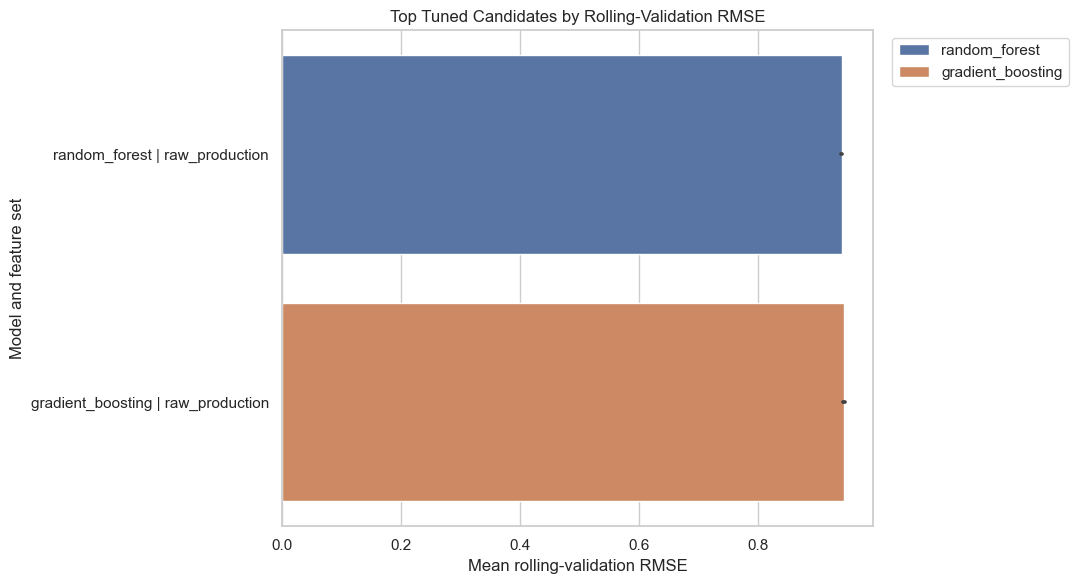

In [13]:
top_tuned = tuning_results_df.head(12).copy()
top_tuned["candidate"] = (
    top_tuned["model"] + " | " + top_tuned["feature_set"]
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=top_tuned,
    x="mean_valid_rmse",
    y="candidate",
    hue="model",
    dodge=False
)
plt.title("Top Tuned Candidates by Rolling-Validation RMSE")
plt.xlabel("Mean rolling-validation RMSE")
plt.ylabel("Model and feature set")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Tuned Model Selection

The selected tuned model is chosen by average rolling-validation RMSE. After selection, it is refit on all development seasons from 2016 through 2023, then evaluated once on the held-out 2024 test season.


In [14]:
best_baseline_row = results_df.iloc[0]
best_tuned_row = tuning_results_df.iloc[0]
best_tuned_params = json.loads(best_tuned_row["params_json"])

# Refit the best untuned baseline on the full development window so the test
# comparison uses the same training seasons as the tuned model.
baseline_key = (best_baseline_row["feature_set"], best_baseline_row["model"])
baseline_features = feature_sets[best_baseline_row["feature_set"]]
baseline_model = make_pipeline(baseline_features, clone(models[best_baseline_row["model"]]))
baseline_model.fit(development_df[baseline_features], development_df[target])
baseline_refit_pred = baseline_model.predict(test_df[baseline_features])
baseline_refit_metrics = evaluate_predictions(test_df[target], baseline_refit_pred)

best_key = (best_tuned_row["feature_set"], best_tuned_row["model"] + "_tuned")
best_features = feature_sets[best_tuned_row["feature_set"]]
best_model_template = clone(tuning_models[best_tuned_row["model"]]).set_params(**best_tuned_params)
best_model = make_pipeline(best_features, best_model_template)
best_model.fit(development_df[best_features], development_df[target])

tuned_test_pred = best_model.predict(test_df[best_features])
tuned_test_metrics = evaluate_predictions(test_df[target], tuned_test_pred)

selection_summary = pd.DataFrame([
    {
        "selection": "best_single_validation_baseline_refit",
        "feature_set": best_baseline_row["feature_set"],
        "model": best_baseline_row["model"],
        "single_validation_rmse": best_baseline_row["valid_rmse"],
        "rolling_validation_rmse": np.nan,
        "test_rmse": baseline_refit_metrics["rmse"],
        "test_r2": baseline_refit_metrics["r2"],
        "params": "default notebook settings"
    },
    {
        "selection": "best_rolling_validation_tuned_refit",
        "feature_set": best_tuned_row["feature_set"],
        "model": best_tuned_row["model"],
        "single_validation_rmse": np.nan,
        "rolling_validation_rmse": best_tuned_row["mean_valid_rmse"],
        "test_rmse": tuned_test_metrics["rmse"],
        "test_r2": tuned_test_metrics["r2"],
        "params": best_tuned_params
    }
])

print("Selected tuned model:", best_key)
print("Best tuned parameters:", best_tuned_params)
display(selection_summary)


Selected tuned model: ('raw_production', 'random_forest_tuned')
Best tuned parameters: {'max_depth': 5, 'max_features': 0.75, 'min_samples_leaf': 10, 'n_estimators': 300}


,selection,feature_set,model,single_validation_rmse,rolling_validation_rmse,test_rmse,test_r2,params
0,best_single_validation_baseline_refit,raw_production,random_forest,0.941482,NaN,0.949882,0.153562,default notebook settings
1,best_rolling_validation_tuned_refit,raw_production,random_forest,NaN,0.937595,0.932052,0.185040,"{'max_depth': 5, 'max_features': 0.75, 'min_sa..."


## Select Best Validation Model

The best model is selected by validation RMSE. Its test-set performance is then used as the best estimate of out-of-sample performance.

In [15]:
# The final selected model is assigned in the tuning section above.
# This cell keeps the original one-season baseline visible for comparison.
best_baseline_row = results_df.iloc[0]
best_baseline_key = (best_baseline_row["feature_set"], best_baseline_row["model"])

print("Best one-season validation baseline:", best_baseline_key)
display(best_baseline_row.to_frame().T)


Best one-season validation baseline: ('raw_production', 'random_forest')


,feature_set,model,n_features,valid_mae,valid_rmse,valid_r2,test_mae,test_rmse,test_r2
7,raw_production,random_forest,9,0.673534,0.941482,0.207063,0.642634,0.939461,0.172031


## Test-Set Predictions and Residuals

Residuals show where the model was too optimistic or too pessimistic. Positive residuals mean the player outperformed the model's prediction for next-season value. Negative residuals mean the player underperformed relative to the prediction.

In [16]:
test_predictions = test_df.copy()
test_predictions["predicted_next_value_score"] = best_model.predict(test_df[best_features])
test_predictions["prediction_residual"] = (
    test_predictions["next_value_score"] - test_predictions["predicted_next_value_score"]
)

display(
    test_predictions[[
        "season", "player_display_name", "position", "team", "games_played",
        "value_score", "next_season", "next_value_score",
        "predicted_next_value_score", "prediction_residual"
    ]]
    .sort_values("prediction_residual", ascending=False)
    .head(15)
)

display(
    test_predictions[[
        "season", "player_display_name", "position", "team", "games_played",
        "value_score", "next_season", "next_value_score",
        "predicted_next_value_score", "prediction_residual"
    ]]
    .sort_values("prediction_residual", ascending=True)
    .head(15)
)


,season,player_display_name,position,team,games_played,value_score,next_season,next_value_score,predicted_next_value_score,prediction_residual
4150,2024,Puka Nacua,WR,LA,11,2.116134,2025.0,6.045016,1.667056,4.377960
4021,2024,George Pickens,WR,PIT,14,0.697599,2025.0,4.125910,0.571445,3.554465
3932,2024,Jonathan Taylor,RB,IND,14,-1.801462,2025.0,2.729041,-0.591630,3.320671
4087,2024,Jaxon Smith-Njigba,WR,SEA,17,1.815221,2025.0,4.230425,1.011574,3.218851
4207,2024,Drake Maye,QB,NE,13,-0.409516,2025.0,3.045983,-0.169209,3.215192
3780,2024,Stefon Diggs,WR,HOU,8,0.327643,2025.0,3.154301,0.270262,2.884039
4052,2024,Trey McBride,TE,ARI,16,2.854003,2025.0,4.421011,2.250251,2.170760
3804,2024,Christian McCaffrey,RB,SF,4,-0.243450,2025.0,1.883956,-0.269553,2.153509
3942,2024,D'Andre Swift,RB,CHI,17,-1.886686,2025.0,1.538396,-0.578594,2.116990
4061,2024,Kyren Williams,RB,LA,16,-1.310114,2025.0,1.503411,-0.542340,2.045751


,season,player_display_name,position,team,games_played,value_score,next_season,next_value_score,predicted_next_value_score,prediction_residual
3945,2024,Justin Jefferson,WR,MIN,17,2.590171,2025.0,-1.301508,1.655752,-2.957260
3954,2024,Jerry Jeudy,WR,CLE,17,1.331729,2025.0,-2.131087,0.647266,-2.778352
4168,2024,Bucky Irving,RB,TB,17,2.403395,2025.0,-1.887972,0.889902,-2.777873
3825,2024,Jonnu Smith,TE,MIA,17,3.436751,2025.0,-0.295940,2.410660,-2.706600
3872,2024,Saquon Barkley,RB,PHI,16,3.243862,2025.0,-2.082095,0.579958,-2.662053
3810,2024,Taysom Hill,TE,NO,8,1.153151,2025.0,-1.609247,0.898331,-2.507578
3833,2024,Alvin Kamara,RB,NO,14,-1.182158,2025.0,-3.041296,-0.637315,-2.403981
3861,2024,Mark Andrews,TE,BAL,17,3.122790,2025.0,-0.041917,2.043826,-2.085743
3893,2024,Tony Pollard,RB,TEN,16,-2.159583,2025.0,-2.457518,-0.445085,-2.012434
4221,2024,Ladd McConkey,WR,LAC,16,2.676800,2025.0,-0.184558,1.627617,-1.812175


## Actual vs Predicted Test Performance

A perfect model would place every point on the diagonal line. In real sports data, prediction is hard because injuries, role changes, team context, coaching, and player development can shift quickly from year to year.

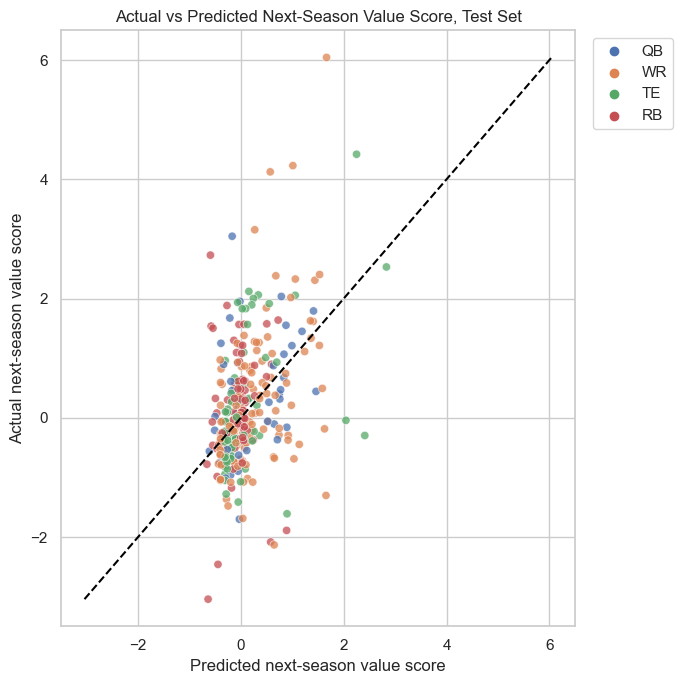

In [17]:
plt.figure(figsize=(7, 7))
sns.scatterplot(
    data=test_predictions,
    x="predicted_next_value_score",
    y="next_value_score",
    hue="position",
    alpha=0.75
)
min_val = min(test_predictions["predicted_next_value_score"].min(), test_predictions["next_value_score"].min())
max_val = max(test_predictions["predicted_next_value_score"].max(), test_predictions["next_value_score"].max())
plt.plot([min_val, max_val], [min_val, max_val], color="black", linestyle="--")
plt.title("Actual vs Predicted Next-Season Value Score, Test Set")
plt.xlabel("Predicted next-season value score")
plt.ylabel("Actual next-season value score")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Permutation Importance for the Selected Model

Permutation importance measures how much model performance gets worse when a feature is randomly shuffled. It is useful because it works with the full pipeline and original input columns.

Correlated features can still split importance, so this should be interpreted as a practical model diagnostic rather than a definitive causal ranking.

In [18]:
importance = permutation_importance(
    best_model,
    test_df[best_features],
    test_df[target],
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

importance_df = (
    pd.DataFrame({
        "feature": best_features,
        "importance_mean": importance.importances_mean,
        "importance_std": importance.importances_std
    })
    .sort_values("importance_mean", ascending=False)
)

importance_df


,feature,importance_mean,importance_std
5,value_epa_total,0.067572,0.012526
0,position,0.036001,0.012973
7,yards_per_game,0.019651,0.006665
6,value_epa_per_game,0.006422,0.006413
3,draft_number,0.004556,0.001684
1,age,0.003583,0.001993
2,years_exp,0.000444,0.001424
4,games_played,0.000095,0.001155
8,tds_per_game,-0.001634,0.003940


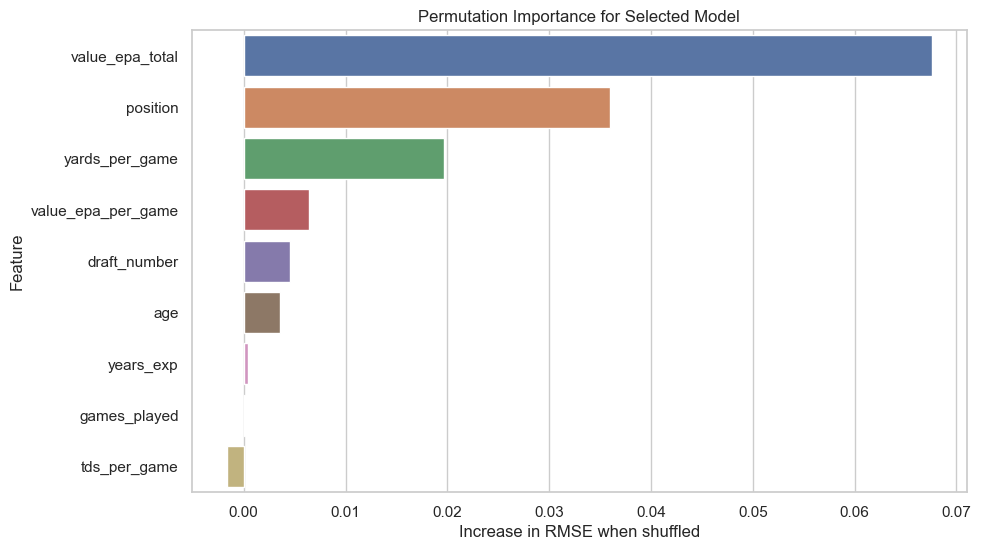

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="importance_mean", y="feature")
plt.title("Permutation Importance for Selected Model")
plt.xlabel("Increase in RMSE when shuffled")
plt.ylabel("Feature")
plt.show()


## Modeling Takeaways

This notebook is designed to answer three questions:

1. Can current-season information predict next-season value better than a simple baseline?
2. Which feature set is most useful without overloading the model with redundant versions of the same signal?
3. Do tuned model settings improve performance when they are chosen with time-aware validation instead of a random split?

The tuned section should be interpreted carefully. Hyperparameter tuning can improve model fit, but it does not fix weak targets, missing context, survivorship bias, or noisy year-to-year NFL performance. In this project, tuning is useful because it makes the model comparison more defensible, not because it guarantees a dramatic accuracy jump.

The next notebook can use salary or cap-hit data to ask a different question: given a player's cost, did he produce more or less value than expected?
